# 01 — EDA & Preprocessing
**Project:** Multilingual (EN/DE/TR) Support Ticket Classification & Priority Prediction
**Phase:** 2 — EDA, Text Cleaning, Class Imbalance Analizi, Train/Val/Test Split


## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option("display.max_colwidth", 100)
sns.set_style("whitegrid")

df = pd.read_json("../Datasets/tickets_combined.jsonl", lines=True)
print("Shape:", df.shape)
df.head(3)


Shape: (32754, 17)


,id,language,subject,body,answer,type,queue,category,priority,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,de_source_000001,de,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gege...",Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersi...,Incident,Technical Support,Technical Issue,high,Security,Outage,Disruption,Data Breach,None,None,None,None
1,en_source_000002,en,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized...","Thank you for reaching out, <name>. We are aware of the outage affecting the centralized account...",Incident,Technical Support,Technical Issue,high,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,en_source_000003,en,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to reques...","Thank you for your inquiry. Our products support integration with Amazon Alexa, Google Assistant...",Request,Returns and Exchanges,Refund,medium,Product,Feature,Tech Support,None,None,None,None,None


## 2. Class Distribution — Language / Category / Priority

In [2]:
print("=== Language Distribution ===")
print(df["language"].value_counts())
print()

print("=== Category Distribution ===")
print(df["category"].value_counts())
print()

print("=== Priority Distribution ===")
print(df["priority"].value_counts())
print()

print("=== Priority x Language Crosstab ===")
print(pd.crosstab(df["language"], df["priority"]))


=== Language Distribution ===
language
en    16308
de    12221
tr     4225
Name: count, dtype: int64

=== Category Distribution ===
category
Technical Issue       19624
Account Management     5759
Billing                3085
General Inquiry        2552
Refund                 1734
Name: count, dtype: int64

=== Priority Distribution ===
priority
medium      11823
high        11796
low          6135
critical     3000
Name: count, dtype: int64

=== Priority x Language Crosstab ===
priority  critical  high   low  medium
language                              
de               0  4824  2513    4884
en               0  6340  3365    6603
tr            3000   632   257     336


## 3. Missing Values and Text Length Distribution

In [3]:
print("=== Missing Values ===")
print(df.isna().sum())
print()

print("=== Text Length (body, characters) ===")
df["body_len"] = df["body"].str.len()
print(df["body_len"].describe())
print()

print("=== Average body length by language ===")
print(df.groupby("language")["body_len"].describe())


=== Missing Values ===
id              0
language        0
subject      3834
body            0
answer          7
type            0
queue           0
category        0
priority        0
tag_1           0
tag_2          13
tag_3         130
tag_4        4396
tag_5       16801
tag_6       26880
tag_7       30714
tag_8       32189
dtype: int64

=== Text Length (body, characters) ===
count    32754.000000
mean       379.828754
std        188.937816
min         20.000000
25%        239.000000
50%        361.500000
75%        535.000000
max       1469.000000
Name: body_len, dtype: float64

=== Average body length by language ===
            count        mean         std   min    25%    50%    75%     max
language                                                                    
de        12221.0  414.018656  221.127568  20.0  227.0  401.0  612.0  1469.0
en        16308.0  368.533787  179.418001  20.0  215.0  377.0  533.0  1147.0
tr         4225.0  324.530178   64.278157  82.0  283.0  321.0 

## 4. Visualization

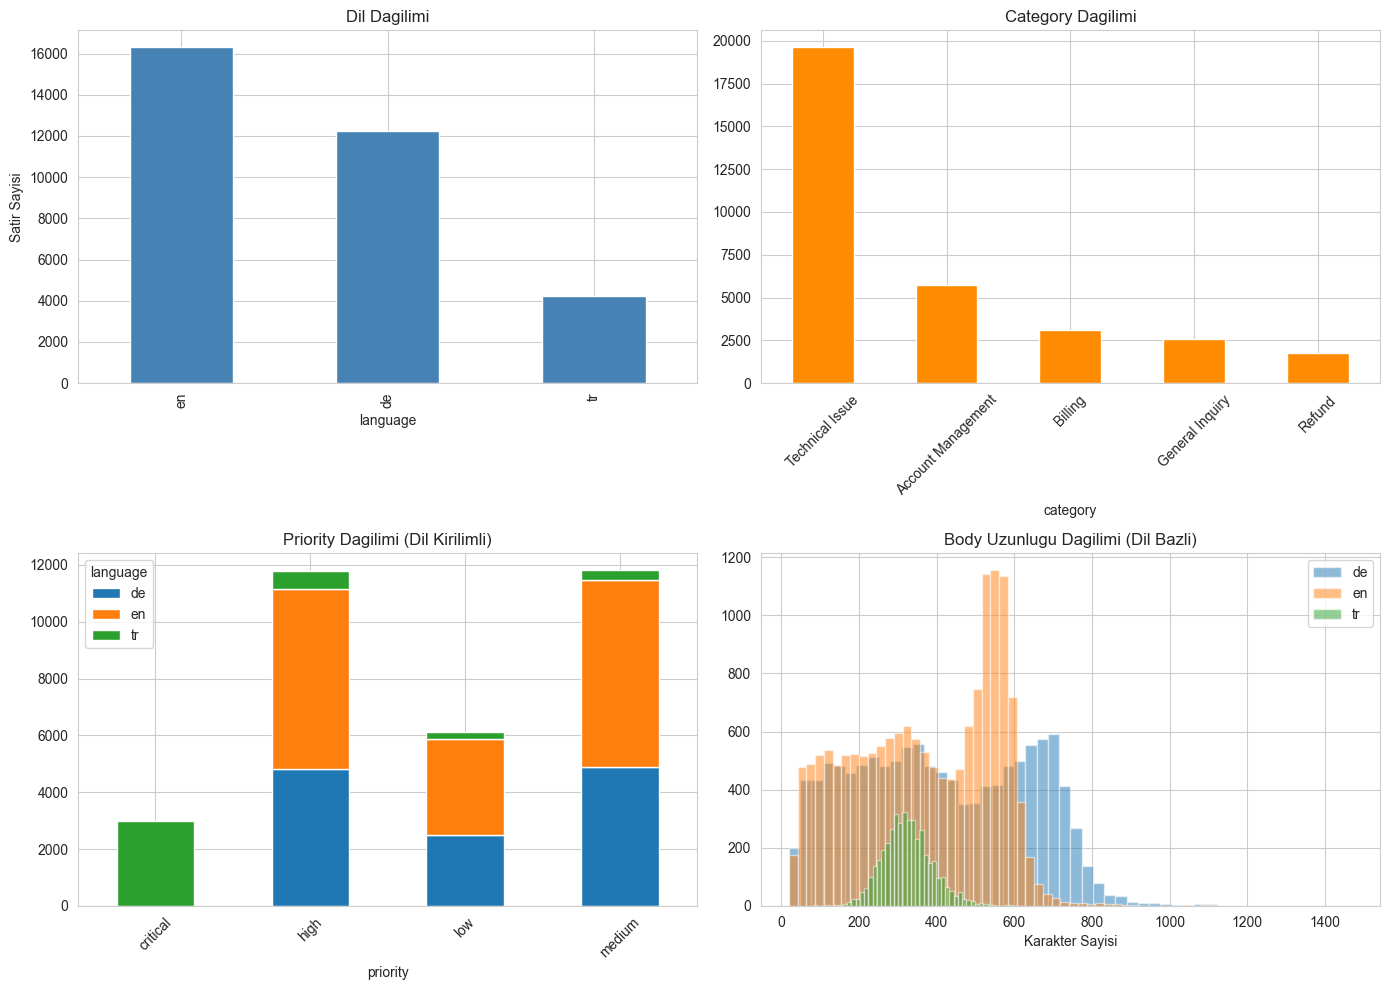

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df["language"].value_counts().plot(kind="bar", ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Language Distribution")
axes[0,0].set_ylabel("Satir Sayisi")

df["category"].value_counts().plot(kind="bar", ax=axes[0,1], color="darkorange")
axes[0,1].set_title("Category Dagilimi")
axes[0,1].tick_params(axis='x', rotation=45)

pd.crosstab(df["priority"], df["language"]).plot(kind="bar", stacked=True, ax=axes[1,0])
axes[1,0].set_title("Priority Dagilimi (Dil Kirilimli)")
axes[1,0].tick_params(axis='x', rotation=45)

for lang in df["language"].unique():
    subset = df[df["language"] == lang]["body_len"]
    axes[1,1].hist(subset, bins=50, alpha=0.5, label=lang)
axes[1,1].set_title("Body Uzunlugu Dagilimi (Dil Bazli)")
axes[1,1].set_xlabel("Karakter Sayisi")
axes[1,1].legend()

plt.tight_layout()
plt.savefig("../data/processed/eda_overview.png", dpi=150)
plt.show()


**Bulgular:**
- `critical` sinifi yalnizca TR verisinde var (EN/DE'de 0 satir) — model dil sinyaline asiri bagimli kalabilir, dil kirilimli degerlendirme (confusion matrix) sart.
- TR body uzunlugu dagilimi cok dar/homojen (std~64), EN/DE cok daha genis (std~179-221) — sentetik verinin "parmak izi" ayri duruyor.
- EN'deki ikinci tepe (480-620 karakter) incelendi: queue/priority dagilimi genel EN dagilimiyla tutarli, "Dear Customer Support Team..." kalibinin dogal tekrari — zararsiz, gercek bir sizinti/duplikasyon degil.


## 5. Text Cleaning Pipeline — Kurulum

In [5]:
# Terminalde (s_env aktifken) once sunlar kurulu olmali:
#   pip install spacy nltk tqdm
#   python -m spacy download en_core_web_sm
#   python -m spacy download de_core_news_sm
#   pip install git+https://github.com/Loodos/zemberek-python.git

import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.corpus import stopwords

stop_en = set(stopwords.words("english"))
stop_de = set(stopwords.words("german"))
stop_tr = set(stopwords.words("turkish"))
stop_tr.update({"bi", "bir", "mi", "mu", "bunu", "şunu", "ona", "bu", "şu", "o"})

print("EN stopwords ornek:", list(stop_en)[:10])
print("DE stopwords ornek:", list(stop_de)[:10])
print("TR stopwords ornek:", list(stop_tr)[:10])


EN stopwords ornek: ['theirs', 'ourselves', 'just', 'do', 'we', 'he', 'so', 'doing', 'y', 'itself']
DE stopwords ornek: ['eurem', 'wollte', 'kein', 'mancher', 'nach', 'manchem', 'dieses', 'anderm', 'dann', 'diese']
TR stopwords ornek: ['bunu', 'gibi', 'mu', 'her', 'hep', 'kim', 'sanki', 'kez', 'bazı', 'acaba']


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mustafa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Mustafa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Mustafa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [6]:
import spacy
from zemberek import TurkishMorphology

nlp_en = spacy.load("en_core_web_sm", disable=["parser", "ner"])
nlp_de = spacy.load("de_core_news_sm", disable=["parser", "ner"])

morphology = TurkishMorphology.create_with_defaults()


2026-07-07 15:14:19,585 - zemberek.morphology.turkish_morphology - INFO
Msg: TurkishMorphology instance initialized in 14.31424617767334



## 6. Temizleme Fonksiyonu

In [7]:
def clean_text(text, language, negation_marker="_NEG"):
    """Lowercasing + placeholder/HTML/noktalama/sayi temizligi + stop-word + lemmatization.
    TR icin: sentence-level disambiguation + negation bilgisini lemma'ya ekleme.
    """
    if not isinstance(text, str) or not text.strip():
        return ""

    text = text.lower()
    text = text.replace("\\n", " ")              # literal "\n" dizisini bosluga cevir
    text = re.sub(r"<[^>]+>", " ", text)          # placeholder + HTML tag temizligi
    text = re.sub(r"[^\w\sçğıöşü]", " ", text)    # TR karakterleri koru, noktalamayi at
    text = re.sub(r"\d+", " ", text)              # sayilari at
    text = re.sub(r"\s+", " ", text).strip()

    if not text:
        return ""

    if language == "en":
        doc = nlp_en(text)
        tokens = [t.lemma_ for t in doc if t.text not in stop_en and len(t.text) > 1]

    elif language == "de":
        doc = nlp_de(text)
        tokens = [t.lemma_ for t in doc if t.text not in stop_de and len(t.text) > 1]

    elif language == "tr":
        sentence_analysis = morphology.analyze_sentence(text)
        disambiguated = morphology.disambiguate(text, sentence_analysis)
        best_analyses = disambiguated.best_analysis()

        raw_tokens = []   # (lemma, is_negative) ciftleri
        for word_analysis in best_analyses:
            if not hasattr(word_analysis, "surface_form"):
                continue
            surface_text = word_analysis.surface_form().lower()
            if surface_text in stop_tr or len(surface_text) <= 1:
                continue

            lemma = str(word_analysis.item.lemma).lower()
            if lemma == "unk":
                lemma = surface_text

            # "duzeltmek" -> yanlislikla "duzelmek" cikma sorunu icin hedefli duzeltme
            if lemma == "düzelmek" and "düzelt" in surface_text:
                lemma = "düzeltmek"

            fstring = word_analysis.format_string() if hasattr(word_analysis, "format_string") else ""
            is_negative = bool(re.search(r":Neg\b", fstring)) and not bool(re.search(r":Imp\b", fstring))
            raw_tokens.append((lemma, is_negative))

        # "-mAk gerekiyor/lazim" (necessity) kalibinda yanlis negation duzeltmesi
        NECESSITY_WORDS = {"gerekmek", "lazım", "icap", "şart"}
        tokens = []
        for i, (lemma, is_negative) in enumerate(raw_tokens):
            next_lemma = raw_tokens[i + 1][0] if i + 1 < len(raw_tokens) else None
            if is_negative and next_lemma in NECESSITY_WORDS:
                tokens.append(lemma)  # yanlis NEG'i kaldir
            else:
                tokens.append(lemma + negation_marker if is_negative else lemma)

    else:
        tokens = text.split()

    return " ".join(tokens)

## 7. Hizli Test (tum veriye uygulamadan once)

In [8]:
sample_en = df[df["language"]=="en"]["body"].iloc[0]
sample_de = df[df["language"]=="de"]["body"].iloc[0]
sample_tr = df[df["language"]=="tr"]["body"].iloc[0]

print("EN orijinal:", sample_en[:150])
print("EN temiz:   ", clean_text(sample_en, "en")[:150])
print()
print("DE orijinal:", sample_de[:150])
print("DE temiz:   ", clean_text(sample_de, "de")[:150])
print()
print("TR orijinal:", sample_tr[:150])
print("TR temiz:   ", clean_text(sample_tr, "tr")[:150])


EN orijinal: Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to
EN temiz:    dear customer support team write report significant problem centralized account management portal currently appear offline outage block access account

DE orijinal: Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betr
DE temiz:    geehrt Support Team möchten gravierend Sicherheitsvorfall melden gegenwärtig mehrere Komponent unser Infrastruktur betreffen betroffen Gerät umfassen 

TR orijinal: <isim>,

Son iki haftadır Antalya şubesinde çalışırken faturamda aşırı miktarda bir fark çıkıyor ve bunu nasıl düzelteceğimi bilmiyorum. Lütfen acilen
TR temiz:    son iki hafta antalya şube çalışmak fatura aşırı miktar fark çıkmak düzeltmek bilmek_NEG lütfen acilen durum incelemek kredi kart son geçerli tarih ya


## 8. Tum Veri Setine Uygulama

EN/DE icin spaCy'nin toplu isleme (`nlp.pipe`) ozelligi kullaniliyor (cok daha hizli).
TR icin zemberek kelime bazli cagrildigindan satir satir isleniyor (4,225 satir, biraz daha yavas ama makul surede biter).


In [ ]:
from tqdm.notebook import tqdm
tqdm.pandas()

def pre_clean(t):
    t = t.lower().replace("\\n", " ")
    t = re.sub(r"<[^>]+>", " ", t)
    t = re.sub(r"[^\w\sçğıöşü]", " ", t)
    t = re.sub(r"\d+", " ", t)
    return re.sub(r"\s+", " ", t).strip()

def clean_dataframe(df):
    cleaned = [None] * len(df)

    for lang, nlp_model, stop_set in [("en", nlp_en, stop_en), ("de", nlp_de, stop_de)]:
        mask = df["language"] == lang
        idx = df.index[mask].tolist()
        texts = df.loc[mask, "body"].fillna("").astype(str)
        pre_cleaned = texts.apply(pre_clean)

        docs = nlp_model.pipe(pre_cleaned.tolist(), batch_size=64)
        for i, doc in zip(idx, tqdm(docs, total=len(idx), desc=f"{lang} temizleniyor")):
            tokens = [t.lemma_ for t in doc if t.text not in stop_set and len(t.text) > 1]
            cleaned[df.index.get_loc(i)] = " ".join(tokens)

    tr_mask = df["language"] == "tr"
    tr_idx = df.index[tr_mask].tolist()
    for i in tqdm(tr_idx, desc="tr temizleniyor"):
        cleaned[df.index.get_loc(i)] = clean_text(df.loc[i, "body"], "tr")

    return cleaned

df["body_clean"] = clean_dataframe(df)
print(df[["language", "body", "body_clean"]].sample(5))


en temizleniyor:   0%|          | 0/16308 [00:00<?, ?it/s]

de temizleniyor:   0%|          | 0/12221 [00:00<?, ?it/s]

tr temizleniyor:   0%|          | 0/4225 [00:00<?, ?it/s]

**Not:** `answer` kolonunu da ayni sekilde temizlemek için (opsiyonel):

```python
df["answer_clean"] = clean_dataframe(df.rename(columns={"answer": "body"}))
```


## 9. Ara Kayit (checkpoint)

In [ ]:
import os
os.makedirs("../data/processed", exist_ok=True)
df.to_json("../data/processed/tickets_cleaned.jsonl", orient="records", lines=True, force_ascii=False)
print("Kaydedildi: ../data/processed/tickets_cleaned.jsonl")
print("Shape:", df.shape)


In [ ]:
test_word = "fiyatlandırma"
sentence_analysis = morphology.analyze_sentence(test_word)
disambiguated = morphology.disambiguate(test_word, sentence_analysis)
best_analyses = disambiguated.best_analysis()

for wa in best_analyses:
    print("surface_form  :", wa.surface_form())
    print("lemma         :", wa.item.lemma)
    print("format_string :", wa.format_string())
    print("item dir()    :", [a for a in dir(wa.item) if not a.startswith("_")])
    print("item.primary_pos varsa:", getattr(wa.item, "primary_pos", "YOK"))
    print("wa.get_pos varsa:", wa.get_pos() if hasattr(wa, "get_pos") else "YOK")
    print("---")

# ayni test icin karsilastirma: gercek negatif fiil
test_word2 = "bilmiyorum"
sentence_analysis2 = morphology.analyze_sentence(test_word2)
disambiguated2 = morphology.disambiguate(test_word2, sentence_analysis2)
for wa in disambiguated2.best_analysis():
    print("surface_form  :", wa.surface_form())
    print("format_string :", wa.format_string())
    print("wa.get_pos varsa:", wa.get_pos() if hasattr(wa, "get_pos") else "YOK")